# 01 — Concept: Scaled Dot-Product & Multi-Head Attention

สถานะ: concept walkthrough (ไม่ต้องพึ่ง `torch`/`numpy` — โค้ดสาธิตในนี้ใช้ pure Python ล้วน)
ก่อนเข้าสู่ implementation จริงใน [`02_from_scratch.ipynb`](02_from_scratch.ipynb)

## 1. Objective

เข้าใจ **ทำไม** กลไก Scaled Dot-Product Attention และ Multi-Head Attention ถูกออกแบบมาแบบนี้ — ไม่ใช่แค่จำสมการได้
แต่ต้องตอบได้ว่าแต่ละองค์ประกอบ (dot product, scale, softmax, multi-head) แก้ปัญหาอะไร และถ้าตัดออกจะเกิดอะไรขึ้น

## 2. Prerequisites

- Linear Algebra: dot product, matrix multiplication
- **Softmax และ gradient ของมัน** — ถ้ายังไม่ชัดตรงนี้ แนะนำให้อ่าน
  [`../docs/softmax.md`](../docs/softmax.md) ก่อน (อธิบายจากศูนย์ พร้อมโค้ดให้ลองเล่น ~15 นาที)
  เพราะหัวข้อ 4.4–4.5 ด้านล่างต่อยอดจากพฤติกรรมของ softmax โดยตรง
- พื้นฐาน Neural Network (Linear layer, non-linearity)

## 3. Hypothesis

- Output ของ `Attention(Q, K, V)` ควรมี shape เท่ากับ `[n_q, d_v]` เสมอ ไม่ขึ้นกับ `d_k`
- แถวของ attention weight (หลัง softmax) ควรรวมกันได้ 1 เสมอ
- เมื่อ `d_k` เพิ่มขึ้นโดยไม่ scale ด้วย `1/√d_k` variance ของ dot product ก่อนเข้า softmax
  ควรเพิ่มขึ้นเป็นสัดส่วนโดยตรงกับ `d_k` (ทดสอบเชิงประจักษ์ใน section 4.4)

## 4. Theory

Paper facts (ตัวเลข, สมการ, ผลการทดลอง) อยู่ใน [`../docs/paper-notes.md`](../docs/paper-notes.md) แบบละเอียด
ส่วนนี้เน้น **intuition** — ทำไมแต่ละส่วนของสมการถึงจำเป็น

### 4.1 Attention คืออะไร ในเชิงสัญชาตญาณ

มองแบบระบบค้นหา (retrieval system): เรามี **query** (สิ่งที่เราอยากรู้) และคลัง **key–value** คู่กัน
(ป้ายกำกับของแต่ละรายการ + เนื้อหาจริงของรายการนั้น) ระบบค้นหาแบบเดิม (hard lookup เช่น dictionary)
จะเลือก value ของ key ที่ตรงกับ query แบบ "เจาะจงอันเดียว" (one-hot)

Attention เปลี่ยนจาก hard lookup เป็น **soft lookup**: แทนที่จะเลือก key เดียว มันคำนวณ "คะแนนความเข้ากัน"
(compatibility score) ระหว่าง query กับ **ทุก** key แล้วแปลงคะแนนเป็นน้ำหนัก (ผ่าน softmax) ที่รวมกันได้ 1
จากนั้นดึง value ออกมาแบบถัวเฉลี่ยถ่วงน้ำหนัก (weighted average) ตามน้ำหนักนั้น

ผลคือ output ที่ query แต่ละตัวได้รับ เป็น "ส่วนผสม" ของ value จากทุกตำแหน่ง โดยตำแหน่งที่ key เข้ากับ
query ดีกว่าจะมีอิทธิพลมากกว่า — สิ่งนี้ทำให้ทั้ง network สามารถ **differentiable** (หา gradient ได้ทุกจุด)
ต่างจาก hard lookup ที่ไม่มี gradient ให้เรียนรู้

### 4.2 ทำไมต้องมี Q, K, V แยกกันสามชุด (ไม่ใช้ vector เดียวกันตรง ๆ)

ในทางทฤษฎี เราอาจใช้ input vector `x` ตรง ๆ เป็นทั้ง query และ key ได้ แต่ paper เลือก **projection**
`x` ผ่าน weight matrix สามชุดที่ต่างกัน (`W_Q`, `W_K`, `W_V`) ก่อน เหตุผลเชิงวิศวกรรม:

- **บทบาทต่างกัน**: "ฉันกำลังมองหาอะไร" (query) กับ "ฉันมีอะไรให้คนอื่นมองหา" (key) กับ "ถ้าถูกเลือก
  ฉันจะส่งข้อมูลอะไรออกไป" (value) เป็นบทบาทที่ต่างกันในเชิง semantic แม้จะมาจาก input ตัวเดียวกัน
  การบังคับให้ vector เดียวทำทั้งสามหน้าที่จะจำกัด representation ที่โมเดลเรียนรู้ได้
- **ปรับมิติได้อิสระ**: `W_Q`, `W_K` โปรเจกต์ไปยัง `d_k` แต่ `W_V` โปรเจกต์ไปยัง `d_v` ซึ่งไม่จำเป็นต้องเท่ากับ
  `d_k` — ทำให้ output dimension ของ attention แยกอิสระจากมิติที่ใช้วัด compatibility ได้

### 4.3 ทำไมใช้ Dot Product วัด "ความเข้ากันได้"

Dot product ระหว่าง vector สองตัว `q · k = Σᵢ qᵢkᵢ` มีความหมายเชิงเรขาคณิต: มันแปรผันตาม
`|q| |k| cos(θ)` โดย `θ` คือมุมระหว่างสอง vector ถ้า normalize ความยาวให้เท่ากัน dot product
ก็คือ cosine similarity นั่นเอง — vector ที่ "ชี้ไปทิศทางเดียวกัน" ใน embedding space จะได้ dot product สูง

เพราะ query/key ทั้งคู่มาจาก learned projection ของ input เดียวกัน โมเดลจึงมีอิสระที่จะจัดเรียง
embedding space ให้ "ทิศทางที่ควรเข้ากัน" ชี้ไปทางเดียวกันได้เอง ระหว่าง training — dot product
เป็นเพียง operation ที่ **ราคาถูก (matrix multiplication เดียว)** และ **differentiable**
สำหรับวัดความสอดคล้องนี้ ไม่ใช่ operation เดียวที่เป็นไปได้ (paper เองก็เทียบกับ additive attention
ใน ablation — ดู [`../docs/paper-notes.md`](../docs/paper-notes.md) ส่วนที่ 11) แต่ dot product
implement เป็น batched matrix multiplication บน GPU ได้เร็วและประหยัด memory กว่า

### 4.4 ทำไมต้อง Scale ด้วย `1/√d_k`

สมมติ component ของ `q` และ `k` แต่ละตัวเป็น random variable ที่ independent กัน มี mean = 0, variance = 1
(ประมาณสภาพหลัง initialization/normalization) ค่า dot product คือผลรวมของ `d_k` พจน์:

```text
q·k = Σᵢ₌₁..d_k  qᵢ kᵢ
```

แต่ละพจน์ `qᵢkᵢ` มี mean = 0 (เพราะ independent, mean 0 ทั้งคู่) และ variance = 1
(variance ของผลคูณตัวแปรสุ่ม mean-0 variance-1 สองตัวที่ independent กัน = 1)
เมื่อบวกกัน `d_k` พจน์ที่ independent กัน **variance รวมกันแบบบวก**: `Var(q·k) = d_k`

นั่นแปลว่ายิ่ง `d_k` มาก ค่า `q·k` ยิ่งมีแนวโน้มกระจายกว้าง (ค่า absolute สูงขึ้น) โดยไม่ได้แปลว่า
"เข้ากันได้ดีขึ้นจริง" — เป็นแค่ผลของขนาดมิติ ไม่ใช่สัญญาณที่มีความหมาย ลอง run เซลล์ถัดไปเพื่อดูว่า
variance นี้โตตาม `d_k` จริงหรือไม่ (สาธิตเชิงประจักษ์ ไม่ใช่แค่ทฤษฎี)

In [9]:
# P2 - Empirical demonstration that Var(q·k) grows linearly with d_k.
# Pure Python (stdlib only) for the computation; matplotlib (project dependency) for the plot below.
import random
import statistics

random.seed(42)


def random_vector(dim: int) -> list[float]:
    # component ~ N(0, 1): mean 0, variance 1
    return [random.gauss(0.0, 1.0) for _ in range(dim)]


def dot(a: list[float], b: list[float]) -> float:
    return sum(ai * bi for ai, bi in zip(a, b))


TRIALS = 2000
D_K_VALUES = (4, 16, 64, 256, 512)

variance_results = {}
print(f"{'d_k':>6} | {'measured Var(q·k)':>20} | {'theory: d_k':>12}")
for d_k in D_K_VALUES:
    scores = [dot(random_vector(d_k), random_vector(d_k)) for _ in range(TRIALS)]
    measured_var = statistics.variance(scores)
    variance_results[d_k] = measured_var
    print(f"{d_k:>6} | {measured_var:>20.2f} | {d_k:>12}")

   d_k |    measured Var(q·k) |  theory: d_k
     4 |                 3.84 |            4
    16 |                16.33 |           16
    64 |                63.35 |           64
   256 |               280.11 |          256
   512 |               506.56 |          512


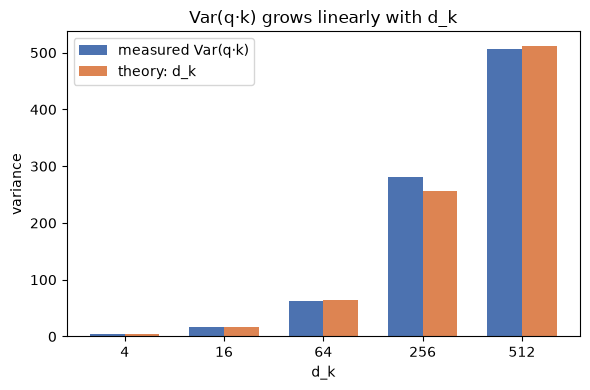

In [10]:
# P2 - Visualize measured vs theoretical Var(q·k) across d_k.
import matplotlib.pyplot as plt

d_ks = list(variance_results.keys())
measured = [variance_results[d] for d in d_ks]

fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(d_ks))
width = 0.35

ax.bar([i - width / 2 for i in x], measured, width, label="measured Var(q·k)", color="#4C72B0")
ax.bar([i + width / 2 for i in x], d_ks, width, label="theory: d_k", color="#DD8452")

ax.set_xticks(list(x))
ax.set_xticklabels([str(d) for d in d_ks])
ax.set_xlabel("d_k")
ax.set_ylabel("variance")
ax.set_title("Var(q·k) grows linearly with d_k")
ax.legend()
fig.tight_layout()
plt.show()

**คาดหวัง:** คอลัมน์ "measured Var(q·k)" ควรใกล้เคียงกับคอลัมน์ "theory: d_k" มากขึ้นเมื่อ `TRIALS` มากพอ
— ถ้าตรงตามนี้ ก็ยืนยัน hypothesis ในหัวข้อ 3 ว่า variance โตเป็นสัดส่วนกับ `d_k` จริง กราฟด้านบนแสดงคู่แท่ง
(measured vs theory) ต่อค่า `d_k` แต่ละค่า — สังเกตว่าคู่แท่งสูงใกล้เคียงกันทุกคู่ และความสูงโดยรวมของทั้งคู่
เพิ่มขึ้นเป็นเส้นตรงเมื่อ `d_k` เพิ่ม (ไม่ใช่ curve โค้ง) ซึ่งคือลักษณะของความสัมพันธ์เชิงเส้น (linear) ตามทฤษฎี

การหารด้วย `√d_k` ทำให้ `Var(q·k / √d_k) = Var(q·k) / d_k = d_k / d_k = 1` — variance กลับมาคงที่
ไม่ว่า `d_k` จะเท่าไหร่ นี่คือเหตุผลที่ scale factor เป็น `√d_k` ไม่ใช่ `d_k` เฉย ๆ หรือค่าคงที่อื่น

### 4.5 ทำไม Variance สูงถึงเป็นปัญหา — เชื่อมกับ Softmax Saturation

Softmax: `softmax(xᵢ) = exp(xᵢ) / Σⱼ exp(xⱒ)` เมื่อค่า input มี variance สูง (บางค่ามากกว่าค่าอื่นมาก)
`exp(·)` จะขยายความต่างนั้นแบบ exponential ทำให้ output เกือบเป็น one-hot (ค่าหนึ่งเข้าใกล้ 1 ที่เหลือเข้าใกล้ 0)

ในสถานะนี้ gradient ของ softmax เทียบกับ input `xᵢ` (ซึ่งมีรูปแบบ `softmax(xᵢ)(1 - softmax(xᵢ))`
สำหรับ diagonal term) จะเข้าใกล้ 0 เพราะ `softmax(xᵢ)` เข้าใกล้ 0 หรือ 1 ทั้งคู่ทำให้พจน์นี้เข้าใกล้ 0
— นี่คือ "บริเวณอิ่มตัว" (saturated region) ที่ backpropagation แทบไม่ส่ง gradient ผ่านไปอัปเดต
weight ที่อยู่ก่อนหน้าเลย โมเดลจึง "เรียนรู้ช้าลงมาก" หรือหยุดเรียนรู้ในจุดนั้น

การ scale ด้วย `1/√d_k` ไม่ได้เปลี่ยนว่า pattern ไหน "เข้ากันดีที่สุด" (ลำดับสัมพัทธ์ของคะแนนเหมือนเดิม)
แต่ควบคุมไม่ให้ค่าก่อนเข้า softmax มีขนาดใหญ่เกินจำเป็นจนเข้าโซนอิ่มตัวเร็วเกินไป

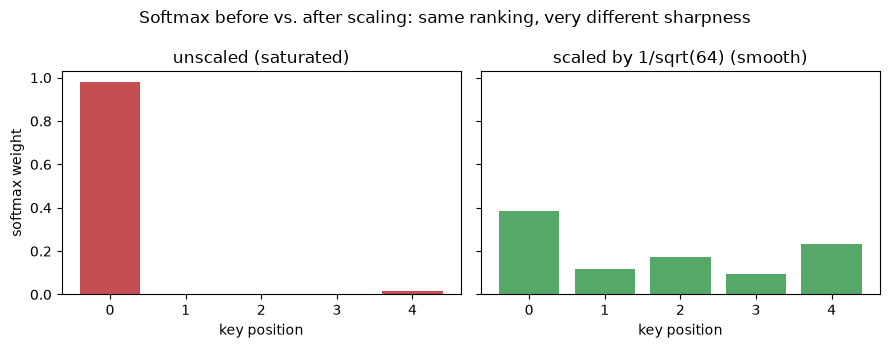

unscaled softmax: [0.9803, 0.0001, 0.0016, 0.0, 0.018]
scaled softmax:   [0.3841, 0.1157, 0.1726, 0.0947, 0.233]


In [11]:
# P2 - Visualize softmax saturation: same relative scores, unscaled vs scaled by 1/sqrt(d_k).
# Note: plot text stays in English -- the default matplotlib font (DejaVu Sans) has no Thai
# glyphs, so Thai labels here would render as missing-glyph boxes. Thai explanation follows below.
import math

import matplotlib.pyplot as plt

# Same *relative pattern* of compatibility scores, at two different d_k (hence two variances).
raw_scores_small_dk = [0.9, -0.3, 0.1, -0.5, 0.4]  # d_k small -> naturally modest spread
raw_scores_large_dk = [x * 8 for x in raw_scores_small_dk]  # d_k large -> unscaled, spread x8

d_k_large = 64


def softmax(xs: list[float]) -> list[float]:
    m = max(xs)
    exps = [math.exp(x - m) for x in xs]
    total = sum(exps)
    return [e / total for e in exps]


unscaled = softmax(raw_scores_large_dk)
scaled = softmax([x / math.sqrt(d_k_large) for x in raw_scores_large_dk])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
positions = range(len(raw_scores_small_dk))

axes[0].bar(positions, unscaled, color="#C44E52")
axes[0].set_title("unscaled (saturated)")
axes[0].set_xlabel("key position")
axes[0].set_ylabel("softmax weight")

axes[1].bar(positions, scaled, color="#55A868")
axes[1].set_title(f"scaled by 1/sqrt({d_k_large}) (smooth)")
axes[1].set_xlabel("key position")

fig.suptitle("Softmax before vs. after scaling: same ranking, very different sharpness")
fig.tight_layout()
plt.show()

print("unscaled softmax:", [round(w, 4) for w in unscaled])
print("scaled softmax:  ", [round(w, 4) for w in scaled])

**อ่านกราฟอย่างไร:** ทั้งสองฝั่งมี compatibility score ที่ **ลำดับเหมือนกันเป๊ะ** (key position 0 เข้ากันดีที่สุด
ในทั้งคู่) แต่ฝั่งซ้าย (ไม่ scale, เสมือนใช้ `d_k` ใหญ่โดยไม่หาร) ได้น้ำหนักเกือบทั้งหมด (`0.98`) ไปที่ตำแหน่งเดียว
ส่วนตำแหน่งอื่นแทบเป็นศูนย์ (`0.0001`–`0.018`) — นี่คือ "saturated": gradient ที่จะไหลย้อนกลับไปปรับ
`W_Q`, `W_K` ผ่านตำแหน่งที่มีน้ำหนักใกล้ 0 นั้นแทบไม่มีเลย เพราะ `softmax(xᵢ)(1-softmax(xᵢ))` ก็ใกล้ 0 ไปด้วย

ฝั่งขวา (scale ด้วย `1/√d_k`) ยังให้น้ำหนักตำแหน่ง 0 มากที่สุด (`0.38`) เหมือนกัน — **ลำดับความสำคัญไม่เปลี่ยน**
แต่กระจายน้ำหนักไปยังตำแหน่งอื่นด้วย (`0.09`–`0.23`) ทำให้ gradient ยังไหลผ่านตำแหน่งเหล่านั้นได้
นี่คือสิ่งที่ scaling แก้ไข: ไม่ใช่ความถูกต้องของคำตอบ แต่คือ "ความสามารถในการเรียนรู้ต่อ" ของโมเดล

### 4.6 ทำไม Multi-Head ดีกว่า Single-Head ขนาดใหญ่

ถ้าใช้ head เดียวขนาด `d_model` เต็ม ๆ softmax ในแต่ละ query จะสร้าง **การถ่วงน้ำหนักชุดเดียว**
ให้ทุกมิติของ output ต้องแชร์กัน ถ้ามีความสัมพันธ์สองแบบที่ต่างกันในประโยคเดียวกัน
(เช่น ความสัมพันธ์เชิงไวยากรณ์ระยะใกล้ กับ ความสัมพันธ์เชิงความหมายระยะไกล) softmax ตัวเดียว
ต้อง "ประนีประนอม" ระหว่างสองรูปแบบนั้นในน้ำหนักชุดเดียว — เป็นการ **เฉลี่ยที่บังคับ** ทำให้ pattern
ที่ชัดเจนทั้งสองแบบเจือจางลง

Multi-head แก้ปัญหานี้โดยแบ่ง projection เป็น `h` ชุดที่เล็กลง (`d_k = d_model/h` ต่อหัว) แต่ละหัวมี
softmax และ output เป็นของตัวเอง อิสระจากหัวอื่น หัวหนึ่งจึงเรียนรู้ที่จะจับ pattern แบบหนึ่ง
ในขณะที่อีกหัวจับอีกแบบได้พร้อมกัน แล้วค่อยรวมผลลัพธ์ (concat) กลับเป็น representation เดียว
ผ่าน `W_O` ทีหลัง — สิ่งนี้ตรวจสอบได้จริงด้วยการ visualize attention weight ของแต่ละหัว
(ดูตัวอย่างจาก paper ใน [`../docs/paper-notes.md`](../docs/paper-notes.md) ส่วนที่ 12)

### 4.7 Self-Attention: Q = K = V มาจากไหน, และ Mask ทำหน้าที่อะไร

**Self-attention** ไม่ใช่กลไกใหม่ — มันคือ attention แบบเดียวกันทุกประการ เพียงแต่ query, key, value
ทั้งสามมาจาก **input sequence เดียวกัน** (ผ่าน projection ต่างกัน) แทนที่จะมาจากสอง sequence ต่างกัน
(เช่น encoder-decoder attention ที่ query มาจาก decoder แต่ key/value มาจาก encoder)

ผลคือทุกตำแหน่งในประโยคสามารถ "ถาม" (query) แล้วดึงข้อมูลจากทุกตำแหน่งอื่นในประโยคเดียวกันได้โดยตรง
ไม่ต้องผ่านตัวกลาง (ต่างจาก RNN ที่ข้อมูลจากตำแหน่งไกล ๆ ต้องไหลผ่าน hidden state ทีละสเต็ป)

**Mask** ใน decoder self-attention คือการบังคับให้คะแนน compatibility ของตำแหน่งที่อยู่ "ในอนาคต"
(ขวามือ) เป็น `-∞` ก่อนเข้า softmax ทำให้หลัง softmax น้ำหนักของตำแหน่งเหล่านั้นเป็น 0 พอดี
— เป็นวิธี implement คุณสมบัติ auto-regressive (ทำนายตำแหน่งถัดไปโดยเห็นแค่ตำแหน่งก่อนหน้า)
แบบขนาน (parallel) ได้ทั้งประโยคในครั้งเดียวตอน training แทนที่จะต้องคำนวณทีละ token

## 5. Mathematics — สมการอ้างอิงและตัวอย่างคำนวณจริง

```text
Attention(Q, K, V) = softmax(QKᵀ / √d_k) V

MultiHead(Q, K, V) = Concat(head_1, ..., head_h) Wᴼ
head_i = Attention(Q Wᵢ_Q, K Wᵢ_K, V Wᵢ_V)
```

Tensor shape (base model, `h=8`, `d_k=d_v=64`, `d_model=512`):

```text
Q, K, V: [n, d_model=512]
      ↓ projection ต่อ head
h=8 หัว × [n, d_k=64]
      ↓ scaled dot-product attention ต่อหัว
h=8 หัว × [n, d_v=64]
      ↓ concat + Wᴼ
[n, d_model=512]
```

ต่อไปนี้เป็นตัวอย่างคำนวณเต็มขั้นตอนด้วยตัวเลขเล็ก ๆ ที่ตั้งขึ้นเอง (ไม่ใช่ข้อมูลจาก paper)
เพื่อให้เห็นว่าตัวเลขไหลผ่านแต่ละขั้นตอนอย่างไรจริง ๆ: `n_q=2` query, `n_k=3` key/value, `d_k=4`, `d_v=3`

In [12]:
# P1 - Hand-worked scaled dot-product attention example (pure Python, illustrative only).
# Shapes: Q [n_q=2, d_k=4], K [n_k=3, d_k=4], V [n_k=3, d_v=3]
import math

Q = [
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 1.0],
]
K = [
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 1.0],
    [1.0, 1.0, 0.0, 0.0],
]
V = [
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
]
d_k = len(Q[0])


def matmul_qkt(q_rows: list[list[float]], k_rows: list[list[float]]) -> list[list[float]]:
    # [n_q, d_k] x [d_k, n_k] -> [n_q, n_k]
    return [[sum(qi * ki for qi, ki in zip(q_row, k_row)) for k_row in k_rows] for q_row in q_rows]


def softmax_row(row: list[float]) -> list[float]:
    m = max(row)  # subtract max for numerical stability
    exps = [math.exp(x - m) for x in row]
    total = sum(exps)
    return [e / total for e in exps]


scores = matmul_qkt(Q, K)  # [n_q, n_k], raw QK^T
scaled = [[s / math.sqrt(d_k) for s in row] for row in scores]  # [n_q, n_k]
weights = [softmax_row(row) for row in scaled]  # [n_q, n_k], each row sums to 1
output = [
    [sum(w * V[j][d] for j, w in enumerate(weight_row)) for d in range(len(V[0]))]
    for weight_row in weights
]  # [n_q, d_v]

print("QK^T (raw scores):")
for row in scores:
    print("  ", [round(x, 3) for x in row])

print(f"\nScaled by 1/sqrt(d_k={d_k}):")
for row in scaled:
    print("  ", [round(x, 3) for x in row])

print("\nAttention weights (softmax, each row sums to 1):")
for row in weights:
    print("  ", [round(x, 3) for x in row], "-> sum =", round(sum(row), 6))

print("\nOutput = weights @ V:")
for row in output:
    print("  ", [round(x, 3) for x in row])

QK^T (raw scores):
   [2.0, 0.0, 1.0]
   [0.0, 2.0, 1.0]

Scaled by 1/sqrt(d_k=4):
   [1.0, 0.0, 0.5]
   [0.0, 1.0, 0.5]

Attention weights (softmax, each row sums to 1):
   [0.506, 0.186, 0.307] -> sum = 1.0
   [0.186, 0.506, 0.307] -> sum = 1.0

Output = weights @ V:
   [0.506, 0.186, 0.307]
   [0.186, 0.506, 0.307]


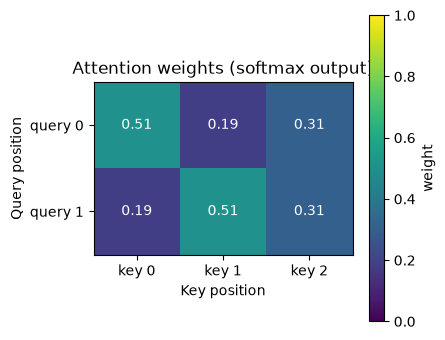

In [13]:
# P2 - Heatmap of the attention weight matrix computed above.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 3.5))
im = ax.imshow(weights, cmap="viridis", vmin=0, vmax=1)

ax.set_xticks(range(len(K)))
ax.set_xticklabels([f"key {j}" for j in range(len(K))])
ax.set_yticks(range(len(Q)))
ax.set_yticklabels([f"query {i}" for i in range(len(Q))])
ax.set_xlabel("Key position")
ax.set_ylabel("Query position")
ax.set_title("Attention weights (softmax output)")

for i in range(len(weights)):
    for j in range(len(weights[i])):
        ax.text(j, i, f"{weights[i][j]:.2f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax, label="weight")
fig.tight_layout()
plt.show()

**อ่านผลลัพธ์อย่างไร (ตัวเลขและ heatmap ด้านบน):**

- Query แถวแรก (`[1, 0, 1, 0]`) เหมือน Key แถวแรกเป๊ะ (`[1, 0, 1, 0]`) จึงควรได้ attention weight
  สูงสุดที่ตำแหน่ง key แรก — ใน heatmap คือช่อง `(query 0, key 0)` ที่มีสีอ่อนที่สุด (ค่า `0.51`)
  เทียบกับอีกสองช่องในแถวเดียวกันที่เข้มกว่า (`0.19`, `0.31`)
- Output แต่ละแถวเป็นผลรวมถ่วงน้ำหนักของแถวใน `V` ตาม attention weight แถวนั้น — สังเกตว่า output
  ไม่ได้เท่ากับแถวใดแถวหนึ่งของ `V` ตรง ๆ แต่เป็น "ส่วนผสม" ตามสัดส่วนน้ำหนัก ตามที่อธิบายไว้ใน 4.1
- ทุกแถวของ attention weight รวมกันได้ 1 พอดี (พิมพ์ `sum =` กำกับไว้) — ยืนยัน hypothesis ข้อ 2 ในหัวข้อ 3
- Output shape คือ `[n_q=2, d_v=3]` ตรงตาม hypothesis ข้อ 1 — ไม่ขึ้นกับ `d_k=4` เลย
- สังเกตความสมมาตร: query 0 กับ query 1 มี pattern น้ำหนักที่ "สลับกัน" ใน heatmap เพราะ Q, K ทั้งสองแถว
  ถูกตั้งให้เป็นภาพสะท้อนกัน (`[1,0,1,0]` กับ `[0,1,0,1]`) — เป็นการตั้งค่าตัวอย่างโดยตั้งใจ เพื่อให้ตรวจสอบ
  ด้วยตาได้ง่ายว่าโมเดล (ตัวอย่างนี้) "จำ" ตำแหน่งที่ตรงกันได้ถูกต้อง

## 6. จุดที่มักเข้าใจผิด (Common Misconceptions)

- **"Attention weight สูง = โมเดล 'สนใจ' แบบมนุษย์"** — attention weight เป็นแค่ผลของ dot product
  หลัง softmax ไม่ได้มีการรับประกันว่าจะตรงกับความสำคัญเชิงความหมายที่มนุษย์เข้าใจเสมอไป ตัวอย่าง
  ใน [`../docs/paper-notes.md`](../docs/paper-notes.md) ส่วนที่ 12 เป็นหลักฐานเชิงคุณภาพ ไม่ใช่การพิสูจน์ทั่วไป
- **"Multi-head แค่เพิ่ม parameter ให้โมเดลใหญ่ขึ้น"** — จริง ๆ แล้วถ้ารักษาผลรวม parameter ให้เท่าเดิม
  (แบ่ง `d_model` เป็น `h` หัว หัวละ `d_model/h`) multi-head แทบไม่เพิ่ม parameter/FLOPs เมื่อเทียบกับ
  single-head ขนาด `d_model` เต็ม — ประโยชน์มาจาก **โครงสร้าง** ที่แยก softmax อิสระต่อหัว ไม่ใช่จากขนาดที่เพิ่มขึ้น
- **"Self-attention ไม่มีความรู้เรื่องลำดับตำแหน่งเลย"** — ถูกครึ่งเดียว: สมการ attention เองไม่รับรู้ตำแหน่งจริง
  (permutation-invariant) แต่โมเดลเต็มไม่ได้ใช้ attention เดี่ยว ๆ มันบวก Positional Encoding เข้ากับ
  input embedding ก่อนเข้า attention เสมอ ความรู้เรื่องตำแหน่งจึงถูก "ฉีด" เข้ามาจากภายนอกกลไก attention

## Next Notebook

→ [`02_from_scratch.ipynb`](02_from_scratch.ipynb): implement Scaled Dot-Product Attention, Multi-Head Attention,
และ Positional Encoding จาก tensor operation พื้นฐาน (ด้วย `torch` แทน pure Python list)